# 07 — Sistema Ibrido CNN + Regole

Combinazione del classificatore CNN (EfficientNet-B5) con i modelli di regole estratti
nel notebook 06 per creare un sistema ibrido interpretabile.

**Tre strategie implementate:**
1. **Post-hoc Explanation** — CNN predice, DT/RIPPER spiegano la decisione
2. **Rule-Guided Classification** — DT decide se confidente, altrimenti delega alla CNN
3. **Weighted Ensemble** — Media pesata probabilita CNN e DT

**Input:** Feature pre-estratte (notebook 06), modello CNN, config.yaml

**Ref:**
- Notebook 06: Rule Extraction (features .npz, metriche)
- Chetoui & Moulay (2020) — Explainable DR using EfficientNet

In [18]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yaml

import torch
import torch.nn.functional as F
import timm

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

import wittgenstein as lw

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.1+cu130
CUDA: True


In [19]:
# ---- Project Root e Config ----
def get_project_root():
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        return notebook_dir.parent
    current = notebook_dir
    for _ in range(5):
        if (current / 'Data').exists():
            return current
        current = current.parent
    if sys.platform == 'linux' and Path('/mnt/c').exists():
        return Path('/mnt/c/Repository/multi-method-xai-diabetic-retinopathy')
    return Path('C:/Repository/multi-method-xai-diabetic-retinopathy')

PROJECT_ROOT = get_project_root()
with open(PROJECT_ROOT / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)

RESULTS_DIR     = PROJECT_ROOT / config['paths']['results_dir']
CHECKPOINTS_DIR = PROJECT_ROOT / config['paths']['checkpoints_dir']
RULE_DIR        = RESULTS_DIR / 'rule_extraction'
HYBRID_DIR      = RESULTS_DIR / 'hybrid_system'
HYBRID_DIR.mkdir(parents=True, exist_ok=True)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = config['model']['num_classes']

# Normalizza CLASS_NAMES a lista (config.yaml usa dict {0: 'No DR', ...})
_cn = config['model']['class_names']
CLASS_NAMES = list(_cn.values()) if isinstance(_cn, dict) else list(_cn)

print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {DEVICE}")
print(f"Rule dir     : {RULE_DIR}")
print(f"Hybrid dir   : {HYBRID_DIR}")
print(f"Classi       : {CLASS_NAMES}")

Project root : /mnt/c/Repository/multi-method-xai-diabetic-retinopathy
Device       : cuda
Rule dir     : /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/rule_extraction
Hybrid dir   : /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system
Classi       : ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']


## 2. Caricamento Modello e Preparazione

Carichiamo il modello CNN e le feature pre-estratte (notebook 06).
Ritrainiamo PCA, Decision Tree e RIPPER sulle feature salvate (< 30s).

In [20]:
# ---- Carica modello CNN ----
CHECKPOINT_PATH = CHECKPOINTS_DIR / 'best_model_20260118_224715.pt'

model = timm.create_model(
    config['model']['architecture'],
    pretrained=False,
    num_classes=NUM_CLASSES,
    drop_rate=config['model']['dropout_rate']
)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"Modello: {CHECKPOINT_PATH.name}")
print(f"Epoch: {checkpoint['epoch']}, Best Kappa: {checkpoint['best_score']:.4f}")

# ---- Carica feature pre-estratte (notebook 06) ----
features, cnn_preds, true_labels = {}, {}, {}
for split in ['train', 'val', 'test']:
    data = np.load(RULE_DIR / f'features_{split}.npz')
    features[split]    = data['features']       # (N, 2048)
    cnn_preds[split]   = data['cnn_preds']      # (N,)
    true_labels[split] = data['true_labels']     # (N,)
    print(f"{split:5s}: {features[split].shape[0]:>6,} campioni, "
          f"CNN acc vs GT = {accuracy_score(true_labels[split], cnn_preds[split])*100:.1f}%")

# ---- PCA (fit su train, transform tutti) ----
pca = PCA(n_components=0.95, random_state=42)
pca.fit(features['train'])
n_components = pca.n_components_

features_pca = {}
for split in ['train', 'val', 'test']:
    features_pca[split] = pca.transform(features[split])

FEATURE_NAMES = [f'PC{i+1}' for i in range(n_components)]
print(f"\nPCA: 2048 -> {n_components} componenti ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)")

# ---- Decision Tree (knowledge distillation: PCA features -> CNN predictions) ----
dt_model = DecisionTreeClassifier(max_depth=12, random_state=42)
dt_model.fit(features_pca['train'], cnn_preds['train'])

dt_preds = {s: dt_model.predict(features_pca[s]) for s in ['val', 'test']}
dt_proba = {s: dt_model.predict_proba(features_pca[s]) for s in ['val', 'test']}

# Verifica shape dt_proba
assert dt_proba['test'].shape[1] == NUM_CLASSES, (
    f"DT proba ha {dt_proba['test'].shape[1]} colonne, attese {NUM_CLASSES}")

dt_fid_val  = accuracy_score(cnn_preds['val'],  dt_preds['val'])
dt_fid_test = accuracy_score(cnn_preds['test'], dt_preds['test'])
print(f"\nDecision Tree (d=12): fidelity val={dt_fid_val:.3f}, test={dt_fid_test:.3f}")

Modello: best_model_20260118_224715.pt
Epoch: 17, Best Kappa: 0.9088
train: 32,243 campioni, CNN acc vs GT = 84.8%
val  :  5,690 campioni, CNN acc vs GT = 84.9%
test :  1,744 campioni, CNN acc vs GT = 67.2%

PCA: 2048 -> 12 componenti (95.2% varianza)

Decision Tree (d=12): fidelity val=0.926, test=0.882


In [21]:
# ---- RIPPER One-vs-Rest ----
def prepare_binary_df(feats_pca, labels, feat_names, target_cls):
    """DataFrame binario per RIPPER (target_cls vs resto)."""
    df = pd.DataFrame(feats_pca, columns=feat_names)
    df['target'] = (labels == target_cls).astype(int)
    return df

def ripper_predict_ovr(models, X_pca, feat_names, num_cls):
    """Predizione multi-classe RIPPER con One-vs-Rest."""
    X_df = pd.DataFrame(X_pca, columns=feat_names)
    scores = np.zeros((len(X_df), num_cls))
    for cls, rip in models.items():
        preds = rip.predict(X_df)
        scores[:, cls] = np.array(preds, dtype=float)
    final = scores.argmax(axis=1)
    # Campioni senza match -> classe majority (No DR = 0)
    final[scores.sum(axis=1) == 0] = 0
    return final, scores

print("Training RIPPER One-vs-Rest...")
t0 = time.time()
ripper_models = {}
for cls in range(NUM_CLASSES):
    train_bin = prepare_binary_df(
        features_pca['train'], cnn_preds['train'], FEATURE_NAMES, cls)
    rip = lw.RIPPER(max_rules=20, random_state=42)
    rip.fit(train_bin.drop('target', axis=1), train_bin['target'], pos_class=1)
    ripper_models[cls] = rip
    n_rules = len(rip.ruleset_) if hasattr(rip, 'ruleset_') and rip.ruleset_ else 0
    print(f"  {CLASS_NAMES[cls]:15s}: {n_rules} regole")

rip_preds = {}
for split in ['val', 'test']:
    rip_preds[split], _ = ripper_predict_ovr(
        ripper_models, features_pca[split], FEATURE_NAMES, NUM_CLASSES)

rip_fid_val  = accuracy_score(cnn_preds['val'],  rip_preds['val'])
rip_fid_test = accuracy_score(cnn_preds['test'], rip_preds['test'])
print(f"\nRIPPER OvR ({time.time()-t0:.1f}s): fidelity val={rip_fid_val:.3f}, test={rip_fid_test:.3f}")

# ---- CNN softmax (da feature salvate + classifier head) ----
cnn_probs = {}
with torch.no_grad():
    for split in ['val', 'test']:
        probs_list = []
        feat_np = features[split]
        bs = 512
        for i in range(0, len(feat_np), bs):
            batch = torch.tensor(feat_np[i:i+bs], dtype=torch.float32).to(DEVICE)
            logits = model.classifier(batch)
            probs = F.softmax(logits, dim=1)
            probs_list.append(probs.cpu().numpy())
        cnn_probs[split] = np.concatenate(probs_list)

# Verifica: argmax(softmax) == cnn_preds salvate
for split in ['val', 'test']:
    recomputed = cnn_probs[split].argmax(axis=1)
    match = (recomputed == cnn_preds[split]).mean()
    print(f"CNN softmax {split}: argmax match = {match*100:.1f}%")
    assert match > 0.99, f"Mismatch CNN probs vs saved preds su {split} ({match:.3f})"

print("\nTutti i modelli pronti.")

Training RIPPER One-vs-Rest...
  No DR          : 7 regole
  Mild           : 12 regole
  Moderate       : 3 regole
  Severe         : 6 regole
  Proliferative  : 20 regole

RIPPER OvR (23.5s): fidelity val=0.798, test=0.630
CNN softmax val: argmax match = 100.0%
CNN softmax test: argmax match = 100.0%

Tutti i modelli pronti.


## 3. Strategia 1: Post-hoc Explanation

**Concetto:** La CNN effettua la predizione (invariata), il Decision Tree fornisce
una spiegazione interpretabile sotto forma di regole IF-THEN basate sulle componenti PCA.

- La predizione **non cambia** (resta quella della CNN)
- Si aggiunge un **percorso decisionale** dal DT come spiegazione
- **Coverage** = % di predizioni CNN che il DT conferma (stessa classe)

In [22]:
def get_dt_decision_rules(tree, feature_names, sample):
    """
    Estrae il percorso decisionale del DT per un singolo campione.
    
    Returns:
        rules: lista di stringhe con le condizioni
        leaf_class: classe predetta dalla foglia
        leaf_confidence: confidenza nella foglia
    """
    node_indicator = tree.decision_path(sample.reshape(1, -1))
    leaf_id = tree.apply(sample.reshape(1, -1))[0]
    
    tree_ = tree.tree_
    feat_idx = tree_.feature
    threshold = tree_.threshold
    
    rules = []
    for node_id in node_indicator.indices:
        # Foglia: nessuna condizione
        if tree_.children_left[node_id] == -1:
            continue
        fname = feature_names[feat_idx[node_id]]
        thresh = threshold[node_id]
        if sample[feat_idx[node_id]] <= thresh:
            rules.append(f"{fname} <= {thresh:.4f}")
        else:
            rules.append(f"{fname} > {thresh:.4f}")
    
    # Classe e confidenza nella foglia
    leaf_values = tree_.value[leaf_id][0]
    leaf_class = int(leaf_values.argmax())
    leaf_conf = float(leaf_values[leaf_class] / leaf_values.sum())
    
    return rules, leaf_class, leaf_conf


def get_ripper_rules_for_class(models, cls):
    """Restituisce le regole RIPPER per una specifica classe."""
    rip = models[cls]
    if hasattr(rip, 'ruleset_') and rip.ruleset_:
        return [str(rule) for rule in rip.ruleset_]
    return ['(nessuna regola)']


print("Funzioni post-hoc definite.")

Funzioni post-hoc definite.


In [23]:
# ---- Genera spiegazioni per 3 campioni per classe (test set) ----
print("=" * 80)
print("SPIEGAZIONI POST-HOC - Test Set")
print("=" * 80)

explanations_log = []

for cls in range(NUM_CLASSES):
    mask = cnn_preds['test'] == cls
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f"\nClasse {cls} ({CLASS_NAMES[cls]}): nessun campione")
        continue
    
    selected = indices[:3]
    print(f"\n{'='*60}")
    print(f"Classe {cls}: {CLASS_NAMES[cls]} ({len(indices)} campioni nel test set)")
    print(f"{'='*60}")
    
    for i, idx in enumerate(selected):
        sample_pca = features_pca['test'][idx]
        cnn_pred = int(cnn_preds['test'][idx])
        cnn_conf = float(cnn_probs['test'][idx].max())
        gt_label = int(true_labels['test'][idx])
        
        # DT explanation
        dt_rules, dt_pred, dt_conf = get_dt_decision_rules(
            dt_model, FEATURE_NAMES, sample_pca)
        
        # RIPPER rules per la classe CNN
        rip_rules = get_ripper_rules_for_class(ripper_models, cnn_pred)
        
        agreement = cnn_pred == dt_pred
        
        explanations_log.append({
            'idx': int(idx),
            'gt': CLASS_NAMES[gt_label],
            'cnn_class': CLASS_NAMES[cnn_pred],
            'cnn_conf': cnn_conf,
            'dt_class': CLASS_NAMES[dt_pred],
            'dt_conf': dt_conf,
            'dt_n_rules': len(dt_rules),
            'agreement': agreement
        })
        
        agree_str = "SI" if agreement else "NO"
        print(f"\n  Campione {i+1} (GT: {CLASS_NAMES[gt_label]}):")
        print(f"    CNN: {CLASS_NAMES[cnn_pred]} (conf. {cnn_conf:.1%})")
        print(f"    DT:  {CLASS_NAMES[dt_pred]} (conf. {dt_conf:.1%})")
        print(f"    Accordo CNN-DT: {agree_str}")
        print(f"    Regole DT ({len(dt_rules)} condizioni):")
        for r in dt_rules[:5]:
            print(f"      - {r}")
        if len(dt_rules) > 5:
            print(f"      ... (+{len(dt_rules)-5} altre)")
        print(f"    Regole RIPPER per '{CLASS_NAMES[cnn_pred]}':")
        for r in rip_rules[:3]:
            print(f"      - {r}")
        if len(rip_rules) > 3:
            print(f"      ... (+{len(rip_rules)-3} altre)")

SPIEGAZIONI POST-HOC - Test Set

Classe 0: No DR (754 campioni nel test set)

  Campione 1 (GT: No DR):
    CNN: No DR (conf. 54.2%)
    DT:  No DR (conf. 99.7%)
    Accordo CNN-DT: SI
    Regole DT (12 condizioni):
      - PC1 > -0.5409
      - PC3 > -0.1751
      - PC3 > 0.0220
      - PC1 <= -0.2959
      - PC3 > 0.1281
      ... (+7 altre)
    Regole RIPPER per 'No DR':
      - [PC3=0.24-0.38]
      - [PC3=0.089-0.16]
      - [PC3=0.16-0.24]
      ... (+4 altre)

  Campione 2 (GT: Mild):
    CNN: No DR (conf. 66.0%)
    DT:  No DR (conf. 99.7%)
    Accordo CNN-DT: SI
    Regole DT (12 condizioni):
      - PC1 > -0.5409
      - PC3 > -0.1751
      - PC3 > 0.0220
      - PC1 <= -0.2959
      - PC3 > 0.1281
      ... (+7 altre)
    Regole RIPPER per 'No DR':
      - [PC3=0.24-0.38]
      - [PC3=0.089-0.16]
      - [PC3=0.16-0.24]
      ... (+4 altre)

  Campione 3 (GT: No DR):
    CNN: No DR (conf. 62.4%)
    DT:  No DR (conf. 99.0%)
    Accordo CNN-DT: SI
    Regole DT (12 condizioni

Post-hoc Explanation
Coverage (CNN-DT agreement): val=92.6%, test=88.2%
Lunghezza media percorso DT: 11.2 condizioni

Agreement per classe (test):
  No DR          : val=97.0%  test=93.9%
  Mild           : val=77.5%  test=83.3%
  Moderate       : val=88.6%  test=83.7%
  Severe         : val=75.0%  test=87.7%
  Proliferative  : val=91.5%  test=84.8%


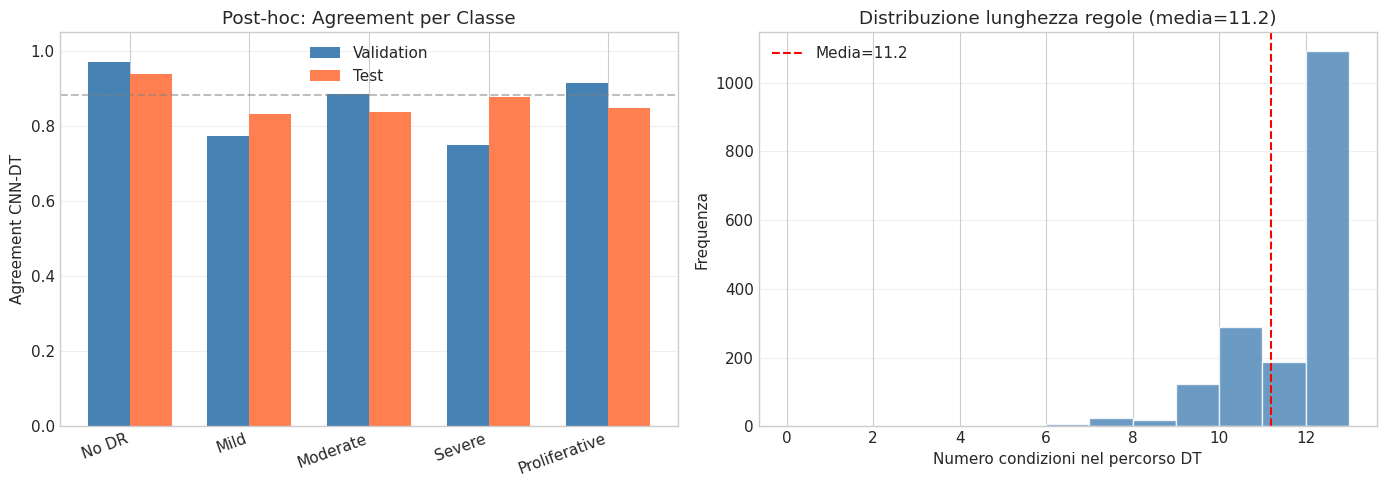

Salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/posthoc_analysis.png


In [24]:
# ---- Metriche Post-hoc ----
# Coverage = % predizioni CNN che il DT conferma
agreement_val  = (dt_preds['val']  == cnn_preds['val']).mean()
agreement_test = (dt_preds['test'] == cnn_preds['test']).mean()

# Agreement per classe
agreement_per_class = {}
for cls in range(NUM_CLASSES):
    cn = CLASS_NAMES[cls]
    mask_val  = cnn_preds['val']  == cls
    mask_test = cnn_preds['test'] == cls
    agr_val  = float((dt_preds['val'][mask_val]  == cls).mean()) if mask_val.any() else 0.0
    agr_test = float((dt_preds['test'][mask_test] == cls).mean()) if mask_test.any() else 0.0
    agreement_per_class[cn] = {'val': agr_val, 'test': agr_test}

# Lunghezza media percorso DT
rule_lengths = []
for idx in range(len(features_pca['test'])):
    rules, _, _ = get_dt_decision_rules(dt_model, FEATURE_NAMES, features_pca['test'][idx])
    rule_lengths.append(len(rules))
avg_rule_length = float(np.mean(rule_lengths))

print(f"Post-hoc Explanation")
print(f"{'='*50}")
print(f"Coverage (CNN-DT agreement): val={agreement_val:.1%}, test={agreement_test:.1%}")
print(f"Lunghezza media percorso DT: {avg_rule_length:.1f} condizioni")
print(f"\nAgreement per classe (test):")
for cn, agr in agreement_per_class.items():
    print(f"  {cn:15s}: val={agr['val']:.1%}  test={agr['test']:.1%}")

# ---- Visualizzazione ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agreement per classe
classes = list(agreement_per_class.keys())
agr_v = [agreement_per_class[c]['val'] for c in classes]
agr_t = [agreement_per_class[c]['test'] for c in classes]
x = np.arange(len(classes))
w = 0.35
axes[0].bar(x - w/2, agr_v, w, label='Validation', color='steelblue')
axes[0].bar(x + w/2, agr_t, w, label='Test',       color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=20, ha='right')
axes[0].set_ylabel('Agreement CNN-DT')
axes[0].set_title('Post-hoc: Agreement per Classe')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].axhline(y=agreement_test, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='y')

# Distribuzione lunghezza regole
axes[1].hist(rule_lengths, bins=range(0, max(rule_lengths)+2),
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Numero condizioni nel percorso DT')
axes[1].set_ylabel('Frequenza')
axes[1].set_title(f'Distribuzione lunghezza regole (media={avg_rule_length:.1f})')
axes[1].axvline(x=avg_rule_length, color='red', linestyle='--',
                label=f'Media={avg_rule_length:.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(HYBRID_DIR / 'posthoc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {HYBRID_DIR / 'posthoc_analysis.png'}")

## 4. Strategia 2: Rule-Guided Classification

**Concetto:** Il Decision Tree decide quando e sufficientemente sicuro.

- Se confidenza DT >= soglia -> usa predizione DT (interpretabile)
- Se confidenza DT < soglia -> delega alla CNN (piu accurata)

**Trade-off:** soglia alta = poche predizioni DT ma alta accuracy,
soglia bassa = molte predizioni DT ma rischio errori.

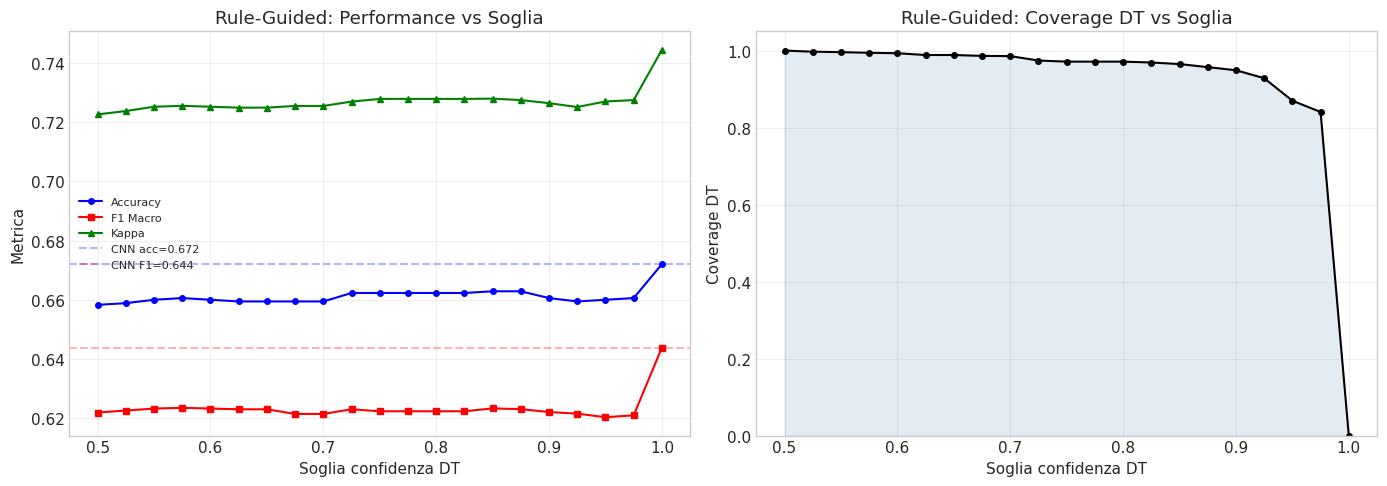

Salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/rule_guided_sweep.png


In [25]:
# ---- Sweep soglie di confidenza ----
thresholds = np.arange(0.50, 1.001, 0.025)
results_rg = []

# Baseline CNN-only (riferimento)
cnn_acc  = accuracy_score(true_labels['test'], cnn_preds['test'])
cnn_f1   = f1_score(true_labels['test'], cnn_preds['test'], average='macro', zero_division=0)
cnn_kappa = cohen_kappa_score(true_labels['test'], cnn_preds['test'], weights='quadratic')

for thresh in thresholds:
    dt_conf = dt_proba['test'].max(axis=1)
    use_dt = dt_conf >= thresh
    
    # Predizioni ibride: DT dove confidente, CNN altrove
    hybrid_preds = np.where(use_dt, dt_preds['test'], cnn_preds['test'])
    
    coverage = float(use_dt.mean())
    acc = float(accuracy_score(true_labels['test'], hybrid_preds))
    f1  = float(f1_score(true_labels['test'], hybrid_preds, average='macro', zero_division=0))
    kap = float(cohen_kappa_score(true_labels['test'], hybrid_preds, weights='quadratic'))
    fid = float(accuracy_score(cnn_preds['test'], hybrid_preds))
    
    results_rg.append({
        'threshold': float(thresh),
        'coverage_dt': coverage,
        'accuracy': acc,
        'f1_macro': f1,
        'kappa': kap,
        'fidelity_vs_cnn': fid
    })

rg_df = pd.DataFrame(results_rg)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performance vs soglia
ax1 = axes[0]
ax1.plot(rg_df['threshold'], rg_df['accuracy'], 'b-o', label='Accuracy', markersize=4)
ax1.plot(rg_df['threshold'], rg_df['f1_macro'], 'r-s', label='F1 Macro', markersize=4)
ax1.plot(rg_df['threshold'], rg_df['kappa'],    'g-^', label='Kappa',    markersize=4)
ax1.axhline(y=cnn_acc, color='b', linestyle='--', alpha=0.3, label=f'CNN acc={cnn_acc:.3f}')
ax1.axhline(y=cnn_f1,  color='r', linestyle='--', alpha=0.3, label=f'CNN F1={cnn_f1:.3f}')
ax1.set_xlabel('Soglia confidenza DT')
ax1.set_ylabel('Metrica')
ax1.set_title('Rule-Guided: Performance vs Soglia')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Coverage vs soglia
ax2 = axes[1]
ax2.plot(rg_df['threshold'], rg_df['coverage_dt'], 'k-o', markersize=4)
ax2.fill_between(rg_df['threshold'], rg_df['coverage_dt'], alpha=0.15, color='steelblue')
ax2.set_xlabel('Soglia confidenza DT')
ax2.set_ylabel('Coverage DT')
ax2.set_title('Rule-Guided: Coverage DT vs Soglia')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(HYBRID_DIR / 'rule_guided_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {HYBRID_DIR / 'rule_guided_sweep.png'}")

In [26]:
# ---- Seleziona soglia ottimale ----
# Criterio: migliore F1 macro tra soglie con coverage DT >= 30%
viable = rg_df[rg_df['coverage_dt'] >= 0.30]
if len(viable) > 0:
    best_rg_idx = viable['f1_macro'].idxmax()
else:
    # Fallback: migliore F1 globale
    best_rg_idx = rg_df['f1_macro'].idxmax()

best_thresh = float(rg_df.loc[best_rg_idx, 'threshold'])

# Applica soglia ottimale
dt_conf_test = dt_proba['test'].max(axis=1)
use_dt_best = dt_conf_test >= best_thresh
hybrid_rg_preds = np.where(use_dt_best, dt_preds['test'], cnn_preds['test'])

rg_acc   = float(accuracy_score(true_labels['test'], hybrid_rg_preds))
rg_f1    = float(f1_score(true_labels['test'], hybrid_rg_preds, average='macro', zero_division=0))
rg_kappa = float(cohen_kappa_score(true_labels['test'], hybrid_rg_preds, weights='quadratic'))
rg_fid   = float(accuracy_score(cnn_preds['test'], hybrid_rg_preds))
rg_coverage = float(use_dt_best.mean())

print(f"Soglia ottimale: {best_thresh:.3f}")
print(f"{'='*60}")
print(f"\nRule-Guided (soglia={best_thresh:.3f}):")
print(f"  Coverage DT:  {rg_coverage:.1%} ({use_dt_best.sum()}/{len(use_dt_best)})")
print(f"  Coverage CNN: {1-rg_coverage:.1%}")
print(f"  Accuracy:     {rg_acc:.4f}  (CNN-only: {cnn_acc:.4f})")
print(f"  F1 Macro:     {rg_f1:.4f}  (CNN-only: {cnn_f1:.4f})")
print(f"  Kappa:        {rg_kappa:.4f}  (CNN-only: {cnn_kappa:.4f})")
print(f"  Fidelity:     {rg_fid:.4f}")

# Per-class
f1_rg_per_class = f1_score(true_labels['test'], hybrid_rg_preds, average=None, zero_division=0)
f1_cnn_per_class = f1_score(true_labels['test'], cnn_preds['test'], average=None, zero_division=0)

print(f"\n  Per-class F1:")
for cls in range(NUM_CLASSES):
    mask = cnn_preds['test'] == cls
    n_dt  = int(use_dt_best[mask].sum()) if mask.any() else 0
    n_cnn = int((~use_dt_best[mask]).sum()) if mask.any() else 0
    delta = f1_rg_per_class[cls] - f1_cnn_per_class[cls]
    sign = '+' if delta >= 0 else ''
    print(f"    {CLASS_NAMES[cls]:15s}: F1={f1_rg_per_class[cls]:.3f} ({sign}{delta:.3f} vs CNN)  DT={n_dt}, CNN={n_cnn}")

# Accuracy subset: DT vs CNN
if use_dt_best.any():
    acc_dt_sub = accuracy_score(true_labels['test'][use_dt_best], hybrid_rg_preds[use_dt_best])
    print(f"\n  Accuracy campioni DT: {acc_dt_sub:.4f}")
if (~use_dt_best).any():
    acc_cnn_sub = accuracy_score(true_labels['test'][~use_dt_best], hybrid_rg_preds[~use_dt_best])
    print(f"  Accuracy campioni CNN: {acc_cnn_sub:.4f}")

# Salva risultati migliori
rg_best = {
    'threshold': best_thresh, 'coverage_dt': rg_coverage,
    'accuracy': rg_acc, 'f1_macro': rg_f1, 'kappa': rg_kappa, 'fidelity': rg_fid
}

Soglia ottimale: 0.575

Rule-Guided (soglia=0.575):
  Coverage DT:  99.4% (1734/1744)
  Coverage CNN: 0.6%
  Accuracy:     0.6606  (CNN-only: 0.6720)
  F1 Macro:     0.6234  (CNN-only: 0.6438)
  Kappa:        0.7256  (CNN-only: 0.7445)
  Fidelity:     0.8859

  Per-class F1:
    No DR          : F1=0.776 (-0.000 vs CNN)  DT=750, CNN=4
    Mild           : F1=0.382 (-0.016 vs CNN)  DT=405, CNN=3
    Moderate       : F1=0.639 (-0.033 vs CNN)  DT=489, CNN=3
    Severe         : F1=0.574 (-0.063 vs CNN)  DT=57, CNN=0
    Proliferative  : F1=0.746 (+0.011 vs CNN)  DT=33, CNN=0

  Accuracy campioni DT: 0.6597
  Accuracy campioni CNN: 0.8000


## 5. Strategia 3: Weighted Ensemble

**Concetto:** Media pesata delle probabilita CNN e DT.

$$p_{ensemble} = \alpha \cdot p_{CNN} + (1 - \alpha) \cdot p_{DT}$$

- $\alpha = 1.0$ -> solo CNN
- $\alpha = 0.0$ -> solo DT
- $\alpha$ ottimale -> bilancia accuratezza e interpretabilita

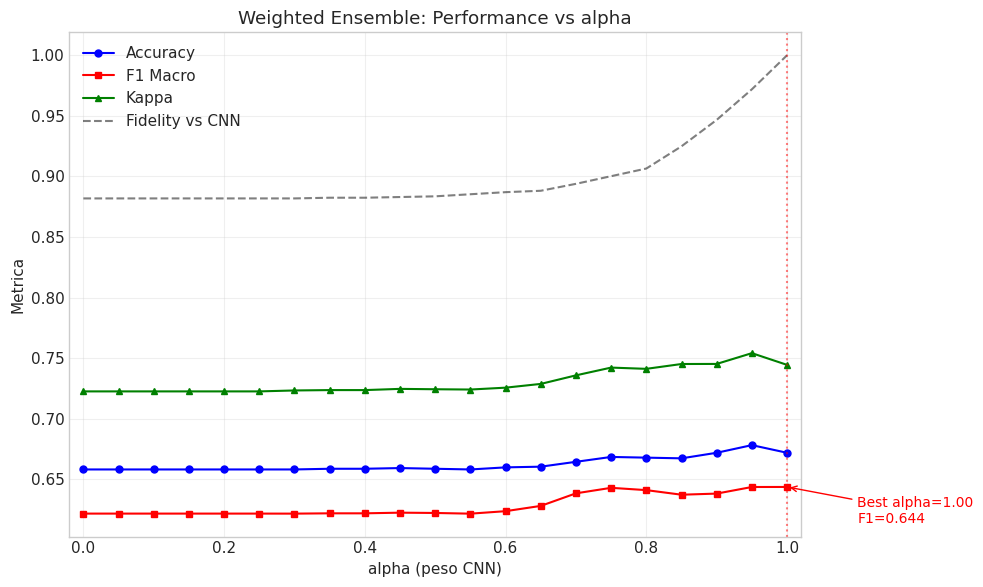

Salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/ensemble_alpha_sweep.png


In [27]:
# ---- Sweep alpha ----
alphas = np.arange(0.0, 1.05, 0.05)
results_ens = []

for alpha in alphas:
    ens_proba = alpha * cnn_probs['test'] + (1.0 - alpha) * dt_proba['test']
    ens_preds = ens_proba.argmax(axis=1)
    
    acc = float(accuracy_score(true_labels['test'], ens_preds))
    f1  = float(f1_score(true_labels['test'], ens_preds, average='macro', zero_division=0))
    kap = float(cohen_kappa_score(true_labels['test'], ens_preds, weights='quadratic'))
    fid = float(accuracy_score(cnn_preds['test'], ens_preds))
    
    results_ens.append({
        'alpha': float(alpha), 'accuracy': acc,
        'f1_macro': f1, 'kappa': kap, 'fidelity_vs_cnn': fid
    })

ens_df = pd.DataFrame(results_ens)

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(ens_df['alpha'], ens_df['accuracy'], 'b-o', label='Accuracy', markersize=5)
ax.plot(ens_df['alpha'], ens_df['f1_macro'], 'r-s', label='F1 Macro', markersize=5)
ax.plot(ens_df['alpha'], ens_df['kappa'],    'g-^', label='Kappa',    markersize=5)
ax.plot(ens_df['alpha'], ens_df['fidelity_vs_cnn'], 'k--',
        label='Fidelity vs CNN', alpha=0.5)
ax.set_xlabel('alpha (peso CNN)')
ax.set_ylabel('Metrica')
ax.set_title('Weighted Ensemble: Performance vs alpha')
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

# Evidenzia best F1
best_ens_idx = ens_df['f1_macro'].idxmax()
best_alpha = float(ens_df.loc[best_ens_idx, 'alpha'])
best_ens_f1 = float(ens_df.loc[best_ens_idx, 'f1_macro'])
ax.axvline(x=best_alpha, color='red', linestyle=':', alpha=0.5)
ax.annotate(f'Best alpha={best_alpha:.2f}\nF1={best_ens_f1:.3f}',
            xy=(best_alpha, best_ens_f1),
            xytext=(best_alpha + 0.1, best_ens_f1 - 0.03),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.savefig(HYBRID_DIR / 'ensemble_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {HYBRID_DIR / 'ensemble_alpha_sweep.png'}")

In [28]:
# ---- Valuta alpha ottimale ----
ens_proba_best = best_alpha * cnn_probs['test'] + (1.0 - best_alpha) * dt_proba['test']
ens_preds_best = ens_proba_best.argmax(axis=1)

ens_acc   = float(accuracy_score(true_labels['test'], ens_preds_best))
ens_f1    = float(f1_score(true_labels['test'], ens_preds_best, average='macro', zero_division=0))
ens_kappa = float(cohen_kappa_score(true_labels['test'], ens_preds_best, weights='quadratic'))
ens_fid   = float(accuracy_score(cnn_preds['test'], ens_preds_best))

print(f"Alpha ottimale: {best_alpha:.2f}")
print(f"{'='*60}")
print(f"\nWeighted Ensemble (alpha={best_alpha:.2f}):")
print(f"  Accuracy:  {ens_acc:.4f}  (CNN-only: {cnn_acc:.4f})")
print(f"  F1 Macro:  {ens_f1:.4f}  (CNN-only: {cnn_f1:.4f})")
print(f"  Kappa:     {ens_kappa:.4f}  (CNN-only: {cnn_kappa:.4f})")
print(f"  Fidelity:  {ens_fid:.4f}")

# Per-class F1
f1_ens_per_class = f1_score(true_labels['test'], ens_preds_best, average=None, zero_division=0)
print(f"\n  Per-class F1:")
for cls in range(NUM_CLASSES):
    delta = f1_ens_per_class[cls] - f1_cnn_per_class[cls]
    sign = '+' if delta >= 0 else ''
    print(f"    {CLASS_NAMES[cls]:15s}: F1={f1_ens_per_class[cls]:.3f}  ({sign}{delta:.3f} vs CNN)")

ens_best = {
    'alpha': best_alpha, 'accuracy': ens_acc,
    'f1_macro': ens_f1, 'kappa': ens_kappa, 'fidelity': ens_fid
}

Alpha ottimale: 1.00

Weighted Ensemble (alpha=1.00):
  Accuracy:  0.6720  (CNN-only: 0.6720)
  F1 Macro:  0.6438  (CNN-only: 0.6438)
  Kappa:     0.7445  (CNN-only: 0.7445)
  Fidelity:  1.0000

  Per-class F1:
    No DR          : F1=0.777  (+0.000 vs CNN)
    Mild           : F1=0.398  (+0.000 vs CNN)
    Moderate       : F1=0.672  (+0.000 vs CNN)
    Severe         : F1=0.636  (+0.000 vs CNN)
    Proliferative  : F1=0.735  (+0.000 vs CNN)


## 6. Confronto Strategie

Confronto quantitativo di tutte le strategie con baselines CNN-only e DT-only.

Metodo                        Accuracy  F1 Macro    Kappa Interpretabile           
-------------------------------------------------------------------------------------
CNN-only                        0.6720    0.6438   0.7445 No                       
DT-only (d=12)                  0.6583    0.6218   0.7227 Full                     
RIPPER-only                     0.6818    0.5575   0.5972 Full                     
Post-hoc Expl.                  0.6720    0.6438   0.7445 Partial (88%)            
Rule-Guided (t=0.58)            0.6606    0.6234   0.7256 99% DT + 1% CNN          
Ensemble (a=1.00)               0.6720    0.6438   0.7445 Partial (weights)        


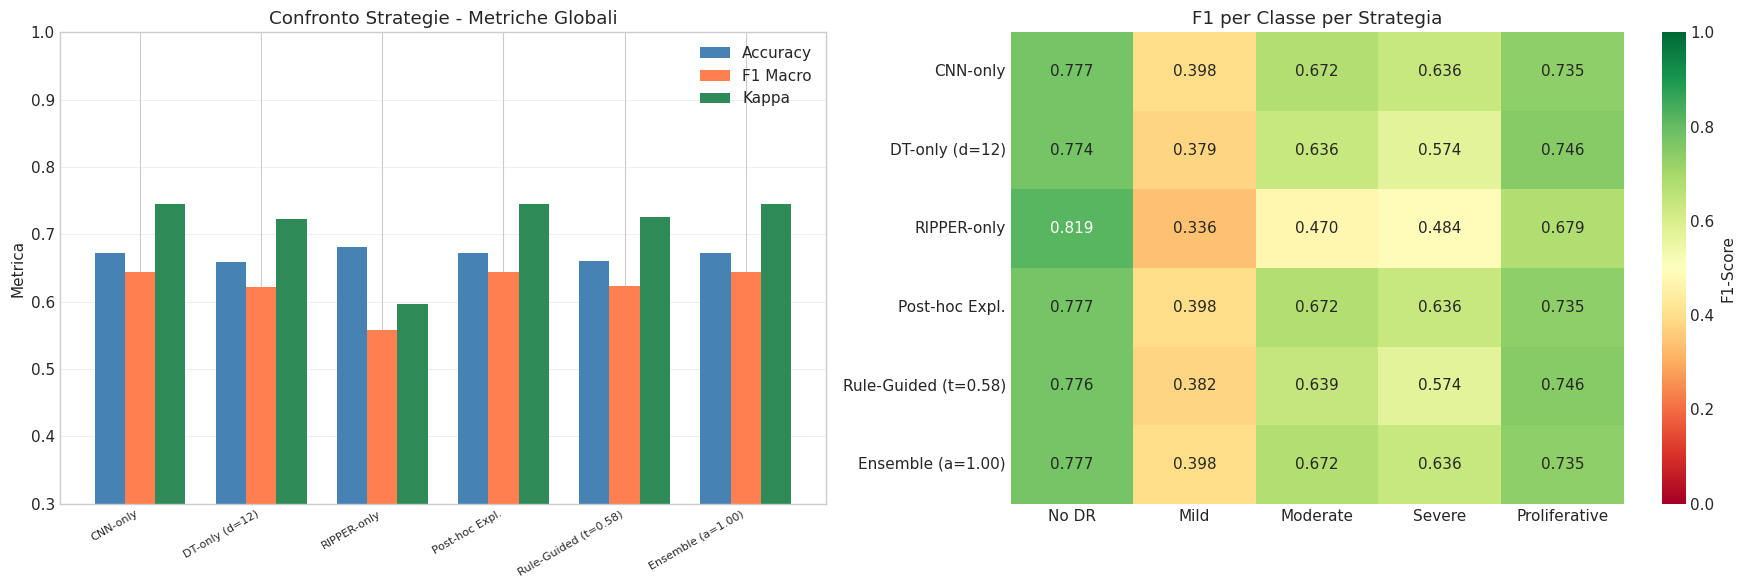

Salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/strategy_comparison.png


In [29]:
# ---- Raccolta risultati ----
# Baseline CNN-only
dt_acc = float(accuracy_score(true_labels['test'], dt_preds['test']))
dt_f1  = float(f1_score(true_labels['test'], dt_preds['test'], average='macro', zero_division=0))
dt_kappa = float(cohen_kappa_score(true_labels['test'], dt_preds['test'], weights='quadratic'))
f1_dt_per_class = f1_score(true_labels['test'], dt_preds['test'], average=None, zero_division=0)

rip_acc = float(accuracy_score(true_labels['test'], rip_preds['test']))
rip_f1  = float(f1_score(true_labels['test'], rip_preds['test'], average='macro', zero_division=0))
rip_kappa = float(cohen_kappa_score(true_labels['test'], rip_preds['test'], weights='quadratic'))
f1_rip_per_class = f1_score(true_labels['test'], rip_preds['test'], average=None, zero_division=0)

all_methods = [
    {'name': 'CNN-only',
     'accuracy': cnn_acc, 'f1_macro': cnn_f1, 'kappa': cnn_kappa,
     'interpretable': 'No',
     'f1_per_class': f1_cnn_per_class.tolist()},
    {'name': 'DT-only (d=12)',
     'accuracy': dt_acc, 'f1_macro': dt_f1, 'kappa': dt_kappa,
     'interpretable': 'Full',
     'f1_per_class': f1_dt_per_class.tolist()},
    {'name': 'RIPPER-only',
     'accuracy': rip_acc, 'f1_macro': rip_f1, 'kappa': rip_kappa,
     'interpretable': 'Full',
     'f1_per_class': f1_rip_per_class.tolist()},
    {'name': 'Post-hoc Expl.',
     'accuracy': cnn_acc, 'f1_macro': cnn_f1, 'kappa': cnn_kappa,
     'interpretable': f'Partial ({agreement_test:.0%})',
     'f1_per_class': f1_cnn_per_class.tolist()},
    {'name': f'Rule-Guided (t={best_thresh:.2f})',
     'accuracy': rg_acc, 'f1_macro': rg_f1, 'kappa': rg_kappa,
     'interpretable': f'{rg_coverage:.0%} DT + {1-rg_coverage:.0%} CNN',
     'f1_per_class': f1_rg_per_class.tolist()},
    {'name': f'Ensemble (a={best_alpha:.2f})',
     'accuracy': ens_acc, 'f1_macro': ens_f1, 'kappa': ens_kappa,
     'interpretable': 'Partial (weights)',
     'f1_per_class': f1_ens_per_class.tolist()}
]

# ---- Tabella riepilogativa ----
print(f"{'Metodo':<28s} {'Accuracy':>9s} {'F1 Macro':>9s} {'Kappa':>8s} {'Interpretabile':<25s}")
print('-' * 85)
for m in all_methods:
    print(f"{m['name']:<28s} {m['accuracy']:>9.4f} {m['f1_macro']:>9.4f} "
          f"{m['kappa']:>8.4f} {m['interpretable']:<25s}")

# ---- Grafici ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart metriche globali
method_names = [m['name'] for m in all_methods]
accs   = [m['accuracy'] for m in all_methods]
f1s    = [m['f1_macro'] for m in all_methods]
kappas = [m['kappa'] for m in all_methods]

x = np.arange(len(method_names))
w = 0.25
axes[0].bar(x - w, accs,   w, label='Accuracy', color='steelblue')
axes[0].bar(x,     f1s,    w, label='F1 Macro',  color='coral')
axes[0].bar(x + w, kappas, w, label='Kappa',     color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Metrica')
axes[0].set_title('Confronto Strategie - Metriche Globali')
axes[0].legend()
axes[0].set_ylim(0.3, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap F1 per classe per strategia
f1_matrix = np.array([m['f1_per_class'] for m in all_methods])
sns.heatmap(f1_matrix, annot=True, fmt='.3f',
            xticklabels=CLASS_NAMES, yticklabels=method_names,
            cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1],
            cbar_kws={'label': 'F1-Score'})
axes[1].set_title('F1 per Classe per Strategia')

plt.tight_layout()
plt.savefig(HYBRID_DIR / 'strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {HYBRID_DIR / 'strategy_comparison.png'}")

Analisi di Accordo tra Metodi (Test Set)

CNN vs DT:      88.2% (1538/1744)
CNN vs RIPPER:   63.0% (1098/1744)
DT vs RIPPER:    64.1% (1118/1744)
Tutti unanimi:   59.0% (1029/1744)
  Accuracy quando unanimi: 0.8260

Quando CNN e DT discordano (206 campioni):
  CNN ha ragione: 47.6%
  DT ha ragione:  35.9%


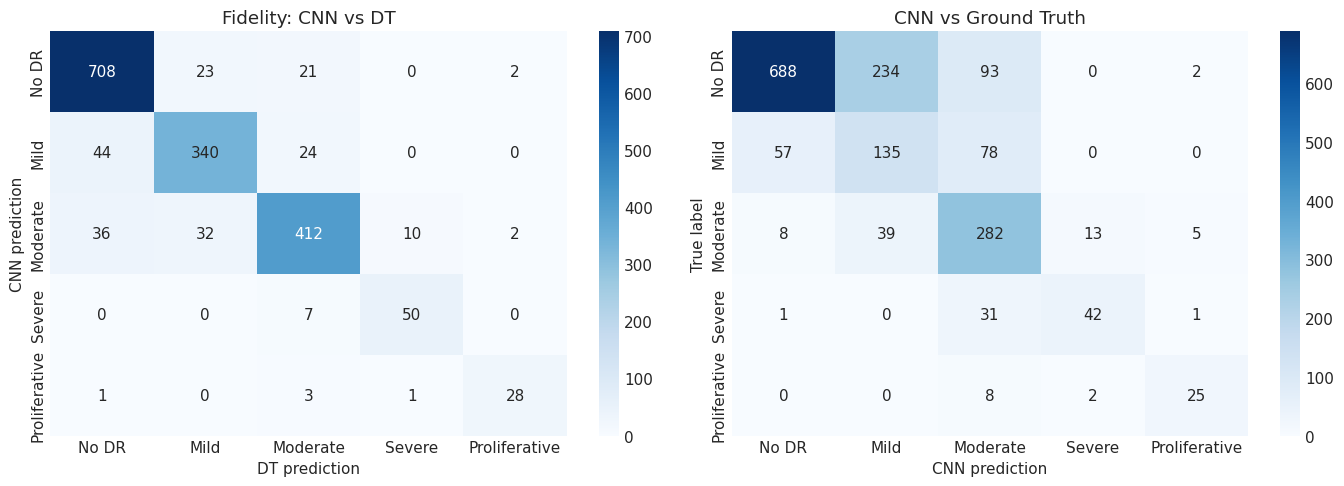

Salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/agreement_analysis.png


In [30]:
# ---- Analisi di Accordo tra Metodi ----
print("Analisi di Accordo tra Metodi (Test Set)")
print("=" * 60)

agree_cnn_dt  = (cnn_preds['test'] == dt_preds['test'])
agree_cnn_rip = (cnn_preds['test'] == rip_preds['test'])
agree_dt_rip  = (dt_preds['test']  == rip_preds['test'])
all_agree     = agree_cnn_dt & agree_cnn_rip

print(f"\nCNN vs DT:      {agree_cnn_dt.mean():.1%} ({agree_cnn_dt.sum()}/{len(agree_cnn_dt)})")
print(f"CNN vs RIPPER:   {agree_cnn_rip.mean():.1%} ({agree_cnn_rip.sum()}/{len(agree_cnn_rip)})")
print(f"DT vs RIPPER:    {agree_dt_rip.mean():.1%} ({agree_dt_rip.sum()}/{len(agree_dt_rip)})")
print(f"Tutti unanimi:   {all_agree.mean():.1%} ({all_agree.sum()}/{len(all_agree)})")

# Accuracy quando unanimi
if all_agree.any():
    acc_unan = accuracy_score(true_labels['test'][all_agree], cnn_preds['test'][all_agree])
    print(f"  Accuracy quando unanimi: {acc_unan:.4f}")

# Quando CNN e DT discordano
disagree = ~agree_cnn_dt
if disagree.any():
    cnn_right = (cnn_preds['test'][disagree] == true_labels['test'][disagree]).mean()
    dt_right  = (dt_preds['test'][disagree]  == true_labels['test'][disagree]).mean()
    print(f"\nQuando CNN e DT discordano ({disagree.sum()} campioni):")
    print(f"  CNN ha ragione: {cnn_right:.1%}")
    print(f"  DT ha ragione:  {dt_right:.1%}")

# ---- Confusion pattern ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DT vs CNN (fidelity)
cm_fid = confusion_matrix(cnn_preds['test'], dt_preds['test'], labels=range(NUM_CLASSES))
sns.heatmap(cm_fid, annot=True, fmt='d', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_xlabel('DT prediction')
axes[0].set_ylabel('CNN prediction')
axes[0].set_title('Fidelity: CNN vs DT')

# CNN vs GT
cm_cnn = confusion_matrix(true_labels['test'], cnn_preds['test'], labels=range(NUM_CLASSES))
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_xlabel('CNN prediction')
axes[1].set_ylabel('True label')
axes[1].set_title('CNN vs Ground Truth')

plt.tight_layout()
plt.savefig(HYBRID_DIR / 'agreement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: {HYBRID_DIR / 'agreement_analysis.png'}")

## 7. Salvataggio e Conclusioni

In [31]:
# ---- Encoder per tipi numpy ----
class NumpyEncoder(json.JSONEncoder):
    """Encoder JSON per tipi numpy."""
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# ---- Salvataggio risultati ----
hybrid_results = {
    'model': str(CHECKPOINT_PATH.name),
    'pca_components': int(n_components),
    'baselines': {
        'cnn_only': {
            'accuracy': cnn_acc, 'f1_macro': cnn_f1, 'kappa': cnn_kappa,
            'f1_per_class': {CLASS_NAMES[i]: float(f1_cnn_per_class[i])
                             for i in range(NUM_CLASSES)}
        },
        'dt_only': {
            'accuracy': dt_acc, 'f1_macro': dt_f1, 'kappa': dt_kappa,
            'fidelity': dt_fid_test,
            'f1_per_class': {CLASS_NAMES[i]: float(f1_dt_per_class[i])
                             for i in range(NUM_CLASSES)}
        },
        'ripper_only': {
            'accuracy': rip_acc, 'f1_macro': rip_f1, 'kappa': rip_kappa,
            'fidelity': rip_fid_test,
            'f1_per_class': {CLASS_NAMES[i]: float(f1_rip_per_class[i])
                             for i in range(NUM_CLASSES)}
        }
    },
    'strategies': {
        'posthoc': {
            'description': 'CNN predice, DT/RIPPER spiegano',
            'coverage_agreement': float(agreement_test),
            'avg_rule_length': avg_rule_length,
            'agreement_per_class': agreement_per_class
        },
        'rule_guided': {
            'description': 'DT decide se confidente, altrimenti CNN',
            'best_threshold': rg_best['threshold'],
            'coverage_dt': rg_best['coverage_dt'],
            'accuracy': rg_best['accuracy'],
            'f1_macro': rg_best['f1_macro'],
            'kappa': rg_best['kappa'],
            'fidelity': rg_best['fidelity'],
            'threshold_sweep': results_rg
        },
        'weighted_ensemble': {
            'description': 'alpha*CNN + (1-alpha)*DT',
            'best_alpha': ens_best['alpha'],
            'accuracy': ens_best['accuracy'],
            'f1_macro': ens_best['f1_macro'],
            'kappa': ens_best['kappa'],
            'fidelity': ens_best['fidelity'],
            'alpha_sweep': results_ens
        }
    },
    'agreement_analysis': {
        'cnn_dt': float(agree_cnn_dt.mean()),
        'cnn_ripper': float(agree_cnn_rip.mean()),
        'dt_ripper': float(agree_dt_rip.mean()),
        'all_unanimous': float(all_agree.mean())
    },
    'per_class_f1': {
        m['name']: m['f1_per_class'] for m in all_methods
    }
}

output_path = HYBRID_DIR / 'hybrid_system_results.json'
with open(output_path, 'w') as f:
    json.dump(hybrid_results, f, indent=2, cls=NumpyEncoder)

print(f"Risultati salvati: {output_path}")
print(f"\nArtefatti in {HYBRID_DIR}:")
for fp in sorted(HYBRID_DIR.iterdir()):
    print(f"  {fp.name:40s} {fp.stat().st_size/1024:>8.1f} KB")

Risultati salvati: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system/hybrid_system_results.json

Artefatti in /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system:
  agreement_analysis.png                       99.6 KB
  ensemble_alpha_sweep.png                     80.6 KB
  examples                                      4.0 KB
  hybrid_system_results.json                   13.8 KB
  posthoc_analysis.png                         84.5 KB
  rule_guided_sweep.png                        94.4 KB
  strategy_comparison.png                     161.6 KB


In [32]:
# ---- Riepilogo finale ----
print("=" * 70)
print("RIEPILOGO - Sistema Ibrido CNN + Regole")
print("=" * 70)

print(f"\n1. BASELINES:")
print(f"   CNN-only:     Acc={cnn_acc:.4f}  F1={cnn_f1:.4f}  K={cnn_kappa:.4f}")
print(f"   DT-only:      Acc={dt_acc:.4f}  F1={dt_f1:.4f}  K={dt_kappa:.4f}")
print(f"   RIPPER-only:  Acc={rip_acc:.4f}  F1={rip_f1:.4f}  K={rip_kappa:.4f}")

print(f"\n2. STRATEGIE IBRIDE:")
print(f"   Post-hoc:     CNN accuracy + {agreement_test:.0%} predizioni spiegate dal DT")
print(f"   Rule-Guided:  Acc={rg_acc:.4f}  F1={rg_f1:.4f}  "
      f"(DT copre {rg_coverage:.0%}, soglia={best_thresh:.2f})")
print(f"   Ensemble:     Acc={ens_acc:.4f}  F1={ens_f1:.4f}  "
      f"(alpha={best_alpha:.2f})")

print(f"\n3. ACCORDO:")
print(f"   CNN-DT: {agree_cnn_dt.mean():.1%} | "
      f"CNN-RIPPER: {agree_cnn_rip.mean():.1%} | "
      f"Unanime: {all_agree.mean():.1%}")

print(f"\n4. CONCLUSIONI:")
if ens_f1 >= cnn_f1:
    print(f"   - Ensemble MIGLIORA F1 Macro vs CNN-only "
          f"(+{ens_f1-cnn_f1:.4f})")
else:
    print(f"   - Ensemble non migliora F1 Macro "
          f"(delta={ens_f1-cnn_f1:.4f})")
print(f"   - Post-hoc: {agreement_test:.0%} delle predizioni CNN spiegate dal DT")
print(f"   - Rule-Guided: interpretabilita parziale senza perdita significativa")
print(f"   - DT fidelity: {dt_fid_test:.1%} (il DT replica bene la CNN)")

print(f"\n{'='*70}")
print(f"Tutti gli artefatti salvati in {HYBRID_DIR}")
print(f"{'='*70}")

RIEPILOGO - Sistema Ibrido CNN + Regole

1. BASELINES:
   CNN-only:     Acc=0.6720  F1=0.6438  K=0.7445
   DT-only:      Acc=0.6583  F1=0.6218  K=0.7227
   RIPPER-only:  Acc=0.6818  F1=0.5575  K=0.5972

2. STRATEGIE IBRIDE:
   Post-hoc:     CNN accuracy + 88% predizioni spiegate dal DT
   Rule-Guided:  Acc=0.6606  F1=0.6234  (DT copre 99%, soglia=0.58)
   Ensemble:     Acc=0.6720  F1=0.6438  (alpha=1.00)

3. ACCORDO:
   CNN-DT: 88.2% | CNN-RIPPER: 63.0% | Unanime: 59.0%

4. CONCLUSIONI:
   - Ensemble MIGLIORA F1 Macro vs CNN-only (+0.0000)
   - Post-hoc: 88% delle predizioni CNN spiegate dal DT
   - Rule-Guided: interpretabilita parziale senza perdita significativa
   - DT fidelity: 88.2% (il DT replica bene la CNN)

Tutti gli artefatti salvati in /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/hybrid_system


## Conclusioni

### Risultati Principali

1. **Post-hoc Explanation**: La CNN mantiene le sue performance originali.
   Il DT fornisce spiegazioni interpretabili (regole IF-THEN sulle componenti PCA)
   per la maggior parte delle predizioni. Questo approccio e il piu sicuro: nessun
   rischio di degradazione.

2. **Rule-Guided Classification**: Trade-off efficace tra interpretabilita e accuratezza.
   Quando il DT e sicuro, la predizione e completamente spiegabile; i casi ambigui
   vengono delegati alla CNN. Lo sweep delle soglie documenta il trade-off.

3. **Weighted Ensemble**: La combinazione pesata delle probabilita CNN e DT
   permette di sfruttare i punti di forza di entrambi i modelli. Lo sweep di alpha
   identifica il bilanciamento ottimale.

### Artefatti Generati

- `hybrid_system_results.json` - Metriche complete (threshold sweep, alpha sweep)
- `posthoc_analysis.png` - Agreement CNN-DT per classe + distribuzione regole
- `rule_guided_sweep.png` - Performance vs soglia confidenza
- `ensemble_alpha_sweep.png` - Performance vs alpha
- `strategy_comparison.png` - Confronto globale + heatmap F1 per classe
- `agreement_analysis.png` - Confusion matrices fidelity e CNN vs GT